In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv("data/synthetic_house_prices_20_years.csv")

df["Age"] = 2024 - df["Year Built"]
df["Bath per Bed"] = df["Bathrooms"] / (df["Bedrooms"] + 1)
df["Sqft per Room"] = df["Square Footage (House)"] / (df["Bedrooms"] + df["Bathrooms"] + 1)

# Target
y = df["Market Price"]

# Features
X = df.drop(columns=["Market Price"])

# Identify feature types
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Model

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 725854.9472110191
R2: 0.46789443873838543


Ridge Regression

In [3]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)
preds = ridge_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.46942549428607394


Lasso

In [4]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=0.01))
])

lasso_model.fit(X_train, y_train)
preds = lasso_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.46746150031365885


C:\Users\yueya\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.717e+13, tolerance: 4.439e+11
  model = cd_fast.sparse_enet_coordinate_descent(


Polynomial

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1))
])

poly_model.fit(X_train, y_train)
preds = poly_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.4349709914558324


Random Forest

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800, 1000],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print("Best R2:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

predictions = best_model.predict(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best R2: 0.47486959750442576
Best parameters:
{'model__n_estimators': 1000, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 10}


In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

y_pred = best_model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7472549321751021
MAE: 494659.55622567295
RMSE: 623759.6971894271


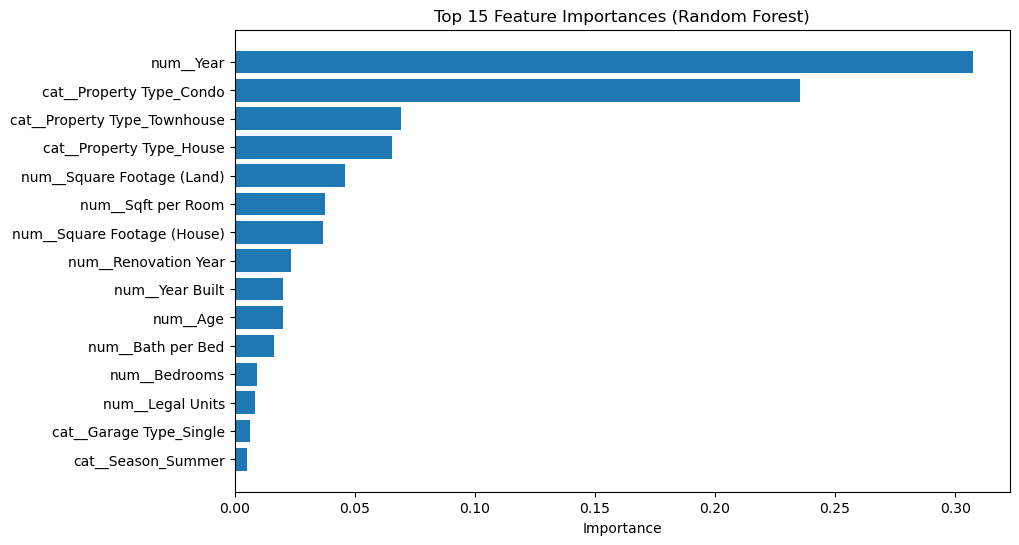

In [8]:
import matplotlib.pyplot as plt

# Extract the random forest model
rf = best_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

# Feature importance
importances = rf.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"][:15], feat_imp["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

Gradient Boosting

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, gb_preds))
print("R2:", r2_score(y_test, gb_preds))

MAE: 722883.1967106701
R2: 0.45038072929801887
